#  Système de Recommandation de Livres

## Objectifs du projet

Ce projet portant sur les systèmes de recommandation a été réalisé dans le cadre du cours Projet Sciences Des Donneées. L'objectif est de construire, comparer et analyser plusieurs approches de recommandation appliquées à un dataset de notes de livres issu kaggle.

Deux grandes familles de méthodes sont explorées :
1. **Filtrage collaboratif (Collaborative Filtering)** - recommander des livres en fonction des comportements d'autres utilisateurs similaires
2. **Filtrage basé sur le contenu (Content-Based Filtering)** - recommander des livres similaires en fonction de leurs descriptions et genres

### Plan du notebook

| Étape | Description |
|-------|-------------|
| 1 | Chargement et exploration initiale des données |
| 2 | Nettoyage et préparation des données |
| 3 | Analyse exploratoire univariée et bivariée |
| 4 | Modélisation CF — Item-Item Cosine (baseline) |
| 5 | Modélisation CF — ALS implicite (approche améliorée) |
| 6 | Clustering sur embeddings ALS (K-Means + Hiérarchique) |
| 7 | Modélisation Content-Based — TF-IDF |
| 8 | Modélisation Content-Based — Jina Embeddings sémantiques |

> **Note** : Ce notebook couvre l'exploration, la préparation et la modélisation. L'évaluation formelle (métriques Precision@K, MAP) fera l'objet de la prochaine unité.

---
## 1. Imports et chargement des données

On commence par importer toutes les bibliothèques nécessaires au projet. Les imports sont regroupés par thématique pour faciliter la lecture :
- **numpy / pandas** : manipulation des données tabulaires et calculs numériques
- **matplotlib / seaborn** : visualisations
- **sklearn** : vectorisation TF-IDF, similarité cosinus, clustering, réduction de dimension
- **scipy.sparse** : stockage efficace de la matrice creuse utilisateur-item
- **collections.Counter** : comptage des genres dans les métadonnées

In [1]:
import os
os.environ["MKL_NUM_THREADS"] = "1"  # évite les warnings de performance Intel MKL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from collections import Counter
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD, PCA
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

# Style global
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Imports OK')

Imports OK


In [3]:
# Chargement des fichiers source
book_id_map  = pd.read_csv('../data/book_id_map.csv')
book_titles  = pd.read_csv('../data/book_titles.csv')
metadata     = pd.read_csv('../data/collaborative_book_metadata.csv')
rating_df    = pd.read_csv('../data/collaborative_books_df.csv')
user_id_map  = pd.read_csv('../data/user_id_map.csv')

print('Fichiers chargés :')
for name, df in [('book_id_map', book_id_map), ('book_titles', book_titles),
                 ('metadata', metadata), ('rating_df', rating_df), ('user_id_map', user_id_map)]:
    print(f'  {name:20s} -> {df.shape[0]:>7,} lignes × {df.shape[1]} colonnes')

Fichiers chargés :
  book_id_map          -> 2,360,650 lignes × 2 colonnes
  book_titles          -> 1,447,341 lignes × 2 colonnes
  metadata             ->      96 lignes × 11 colonnes
  rating_df            -> 196,296 lignes × 7 colonnes
  user_id_map          -> 876,145 lignes × 2 colonnes


---
## 2. Exploration initiale — aperçu de chaque dataset
Avant toute transformation, on audite chaque fichier source : dimensions, types de colonnes, valeurs manquantes et doublons. La fonction `overview_plus` centralise ces vérifications pour éviter de répéter le même code cinq fois.

Les cinq fichiers chargés sont :
- `rating_df` : les notes des utilisateurs (196 000+ lignes) - fichier principal
- `metadata` : métadonnées textuelles de 96 livres (descriptions, genres) - utilisé pour le contenu
- `book_titles` : table titres / identifiants pour l'affichage
- `book_id_map` : correspondance entre l'identifiant CSV séquentiel et l'identifiant Goodreads
- `user_id_map` : correspondance des identifiants utilisateurs

In [4]:
def overview_plus(df, name, n=5):
    """Affiche un aperçu complet d'un DataFrame : head, types, manquants, doublons."""
    print('\n' + '='*60)
    print(f'{name}  ->  {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
    print('='*60)
    display(df.head(n))
    print('\n--- Types et non-nuls ---')
    df.info()
    print('\n--- Valeurs manquantes ---')
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    print('Aucune valeur manquante ' if miss.empty else miss)
    print(f'\n--- Doublons : {df.duplicated().sum()} ---')

overview_plus(book_id_map,  'book_id_map')
overview_plus(book_titles,  'book_titles')
overview_plus(metadata,     'metadata (brut)')
overview_plus(rating_df,    'rating_df (brut)')
overview_plus(user_id_map,  'user_id_map')


book_id_map  ->  2,360,650 lignes, 2 colonnes


,book_id_csv,book_id
0,0,34684622
1,1,34536488
2,2,34017076
3,3,71730
4,4,30422361



--- Types et non-nuls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2360650 entries, 0 to 2360649
Data columns (total 2 columns):
 #   Column       Dtype
---  ------       -----
 0   book_id_csv  int64
 1   book_id      int64
dtypes: int64(2)
memory usage: 36.0 MB

--- Valeurs manquantes ---
Aucune valeur manquante 

--- Doublons : 0 ---

book_titles  ->  1,447,341 lignes, 2 colonnes


,title,book_id
0,The Unschooled Wizard Sun Wolf and Starhawk 12,7327624
1,Best Friends Forever,6066819
2,The Aeneid for Boys and Girls,287141
3,Alls Fairy in Love and War Avalon Web of Magic 8,6066812
4,The Devils Notebook,287149



--- Types et non-nuls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447341 entries, 0 to 1447340
Data columns (total 2 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   title    1437948 non-null  object
 1   book_id  1447341 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 22.1+ MB

--- Valeurs manquantes ---
title    9393
dtype: int64

--- Doublons : 0 ---

metadata (brut)  ->  96 lignes, 11 colonnes


...


--- Types et non-nuls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       96 non-null     int64 
 1   book_id          96 non-null     int64 
 2   title            96 non-null     object
 3   image_url        96 non-null     object
 4   url              96 non-null     object
 5   num_pages        96 non-null     int64 
 6   ratings_count    96 non-null     int64 
 7   description      96 non-null     object
 8   genre            96 non-null     object
 9   name             96 non-null     object
 10  book_id_mapping  96 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 8.4+ KB

--- Valeurs manquantes ---
Aucune valeur manquante 

--- Doublons : 0 ---

rating_df (brut)  ->  196,296 lignes, 7 colonnes


,Unnamed: 0,title,book_id,user_id_mapping,book_id_mapping,Predicted Rating,Actual Rating
0,0,I Am the Messenger,19057,1537,299,4.5,5
1,1,I Am the Messenger,19057,23039,299,4.9,3
2,2,I Am the Messenger,19057,39096,299,3.9,3
3,3,I Am the Messenger,19057,14631,299,4.7,4
4,4,I Am the Messenger,19057,32816,299,4.3,5



--- Types et non-nuls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196296 entries, 0 to 196295
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        196296 non-null  int64  
 1   title             196296 non-null  object 
 2   book_id           196296 non-null  int64  
 3   user_id_mapping   196296 non-null  int64  
 4   book_id_mapping   196296 non-null  int64  
 5   Predicted Rating  196296 non-null  float64
 6   Actual Rating     196296 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 10.5+ MB

--- Valeurs manquantes ---
Aucune valeur manquante 

--- Doublons : 0 ---

user_id_map  ->  876,145 lignes, 2 colonnes


,user_id_csv,user_id
0,0,8842281e1d1347389f2ab93d60773d4d
1,1,72fb0d0087d28c832f15776b0d936598
2,2,ab2923b738ea3082f5f3efcbbfacb218
3,3,d986f354a045ffb91234e4af4d1b12fd
4,4,7504b2aee1ecb5b2872d3da381c6c91e



--- Types et non-nuls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876145 entries, 0 to 876144
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   user_id_csv  876145 non-null  int64 
 1   user_id      876145 non-null  object
dtypes: int64(1), object(1)
memory usage: 13.4+ MB

--- Valeurs manquantes ---
Aucune valeur manquante 

--- Doublons : 0 ---


---
## 3. Nettoyage et préparation des données
Le nettoyage est volontairement ciblé : on ne traite que ce qui est nécessaire aux deux pipelines. Inutile de normaliser des colonnes qu'on n'utilisera jamais.
### 3.1 Nettoyage de `rating_df`

In [5]:
# Supprimer l'index parasite et renommer les colonnes
if 'Unnamed: 0' in rating_df.columns:
    rating_df = rating_df.drop(columns=['Unnamed: 0'])

rating_df = rating_df.rename(columns={
    'Predicted Rating': 'pred_rating',
    'Actual Rating':    'rating'
})
rating_df['rating'] = rating_df['rating'].astype(float)

print(f'Doublons       : {rating_df.duplicated().sum()}')
print(f'Valeurs manq.  : {rating_df.isna().sum().sum()}')
print(f'Shape finale   : {rating_df.shape}')
display(rating_df.head())

Doublons       : 0
Valeurs manq.  : 0
Shape finale   : (196296, 6)


,title,book_id,user_id_mapping,book_id_mapping,pred_rating,rating
0,I Am the Messenger,19057,1537,299,4.5,5.0
1,I Am the Messenger,19057,23039,299,4.9,3.0
2,I Am the Messenger,19057,39096,299,3.9,3.0
3,I Am the Messenger,19057,14631,299,4.7,4.0
4,I Am the Messenger,19057,32816,299,4.3,5.0


**Résultat** : `rating_df` est dans un état propre dès le départ - aucun doublon, aucune valeur manquante. Le renommage des colonnes (`Predicted Rating` -> `pred_rating`, `Actual Rating` -> `rating`) rend le code plus lisible dans la suite. La conversion en `float` est nécessaire pour les calculs de similarité.

### 3.2 Nettoyage de `metadata`
On supprime les colonnes sans valeur analytique (`image_url`, `url`, `name`) et on normalise les espaces sur les colonnes textuelles. La colonne `name` (auteur) est retirée car elle n'est pas exploitée dans le pipeline TF-IDF.

In [6]:
# Supprimer les colonnes inutiles
cols_to_drop = [c for c in ['Unnamed: 0', 'image_url', 'url', 'name'] if c in metadata.columns]
metadata = metadata.drop(columns=cols_to_drop)

# Normaliser les colonnes textuelles
for col in ['title', 'description', 'genre']:
    metadata[col] = metadata[col].astype(str).str.strip()

print(f'Shape metadata nettoyé : {metadata.shape}')
display(metadata.head())

Shape metadata nettoyé : (96, 7)


,book_id,title,num_pages,ratings_count,description,genre,book_id_mapping
0,5899779,Pride and Prejudice and Zombies Pride and Prej...,320,105537,The New York Times Best Seller is now a major ...,"['fantasy, paranormal', 'romance', 'fiction', ...",808
1,872333,Blue Bloods Blue Bloods 1,302,117633,"When the Mayflower set sail in 1620, it carrie...","['young-adult', 'fantasy, paranormal', 'romanc...",217
2,15507958,Me Before You Me Before You 1,369,609327,Louisa Clark is an ordinary young woman living...,"['romance', 'fiction']",385
3,66559,Sharp Objects,254,208394,"Fresh from a brief stay at a psych hospital, r...","['mystery, thriller, crime', 'fiction']",192
4,7235533,The Way of Kings The Stormlight Archive 1,1007,151473,"Speak again the ancient oaths,\nLife before de...","['fantasy, paranormal', 'fiction']",873


### 3.3 Nettoyage de `book_titles`
`book_titles` contient ~9 400 titres manquants sur 1,4 million de lignes. On les supprime car cette table sert uniquement à l'affichage - une ligne sans titre n'apporte rien.

In [7]:
book_titles = book_titles.dropna(subset=['title'])
book_titles['title'] = book_titles['title'].str.strip()
book_titles = book_titles[book_titles['title'] != '']

print(f'Valeurs manquantes après nettoyage : {book_titles.isna().sum().to_dict()}')
print(f'Shape : {book_titles.shape}')

Valeurs manquantes après nettoyage : {'title': 0, 'book_id': 0}
Shape : (1384641, 2)


### 3.4 Construction du dataset de notes

On extrait les trois colonnes strictement nécessaires au filtrage collaboratif. Le `.copy()` est important : sans lui, toute modification sur `ratings` affecterait aussi `rating_df`.

In [8]:
ratings = rating_df[['user_id_mapping', 'book_id_mapping', 'rating']].copy()
print(f'Shape ratings : {ratings.shape}')
display(ratings.head())

Shape ratings : (196296, 3)


,user_id_mapping,book_id_mapping,rating
0,1537,299,5.0
1,23039,299,3.0
2,39096,299,3.0
3,14631,299,4.0
4,32816,299,5.0


---
## 4. Analyse Exploratoire des Données (EDA)

### 4.1 Distribution des notes
On commence par regarder comment se répartissent les notes entre 1 et 5. Cette étape est fondamentale : elle conditionne le traitement des données en amont de la modélisation.

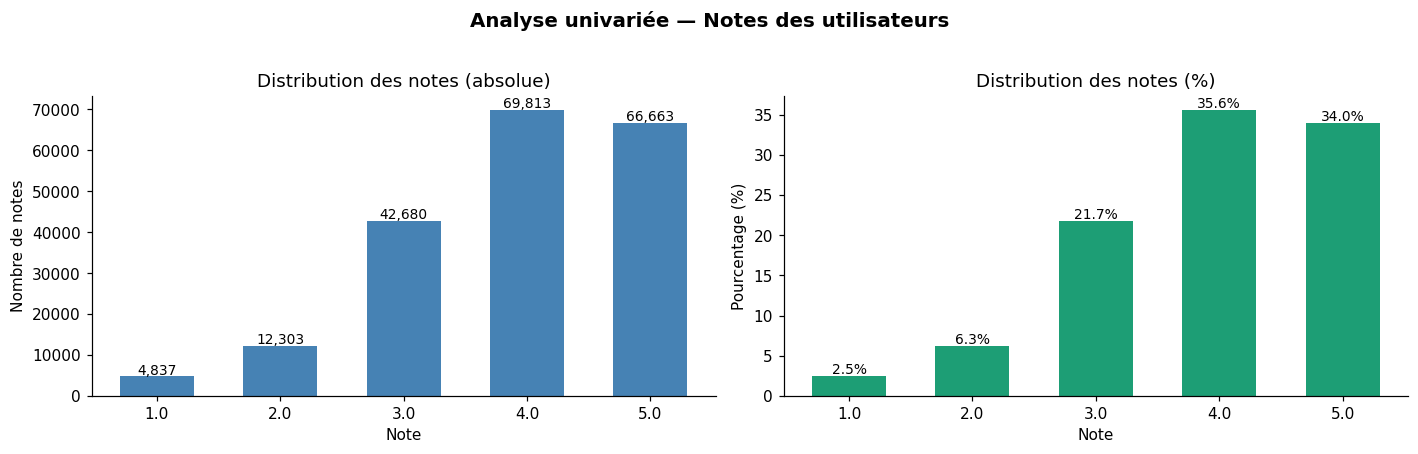


Statistiques descriptives :
count    196296.00
mean          3.92
std           1.01
min           1.00
25%           3.00
50%           4.00
75%           5.00
max           5.00
Name: rating, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution absolue
note_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(note_counts.index.astype(str), note_counts.values, color='steelblue', width=0.6)
axes[0].set_title('Distribution des notes (absolue)')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre de notes')
for i, v in enumerate(note_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Distribution relative
note_pct = note_counts / note_counts.sum() * 100
axes[1].bar(note_pct.index.astype(str), note_pct.values, color='#1D9E75', width=0.6)
axes[1].set_title('Distribution des notes (%)')
axes[1].set_xlabel('Note')
axes[1].set_ylabel('Pourcentage (%)')
for i, v in enumerate(note_pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Analyse univariée — Notes des utilisateurs', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nStatistiques descriptives :')
print(ratings['rating'].describe().round(2))

**Ce qu'on observe** : les notes 4 et 5 représentent la grande majorité des évaluations. C'est un biais très courant dans les datasets de recommandation publics - les utilisateurs notent surtout ce qu'ils ont aimé. Les notes 1 et 2 sont rares, ce qui rend la détection des "dislikes" plus délicate. Ce constat influence directement le choix de binariser les données pour ALS (on conserve uniquement les likes, notes >= 4).

### 4.2 Analyse univariée - Activité des utilisateurs et des livres

On regarde combien de notes chaque utilisateur a données, et combien chaque livre en a reçues. Ces deux distributions permettent de caractériser le problème de sparsité et de calibrer les seuils de filtrage.

Notes par user  → mean: 2.93 | median: 2.0 | max: 22
Notes par livre → mean: 218.59 | median: 165.5 | max: 1296


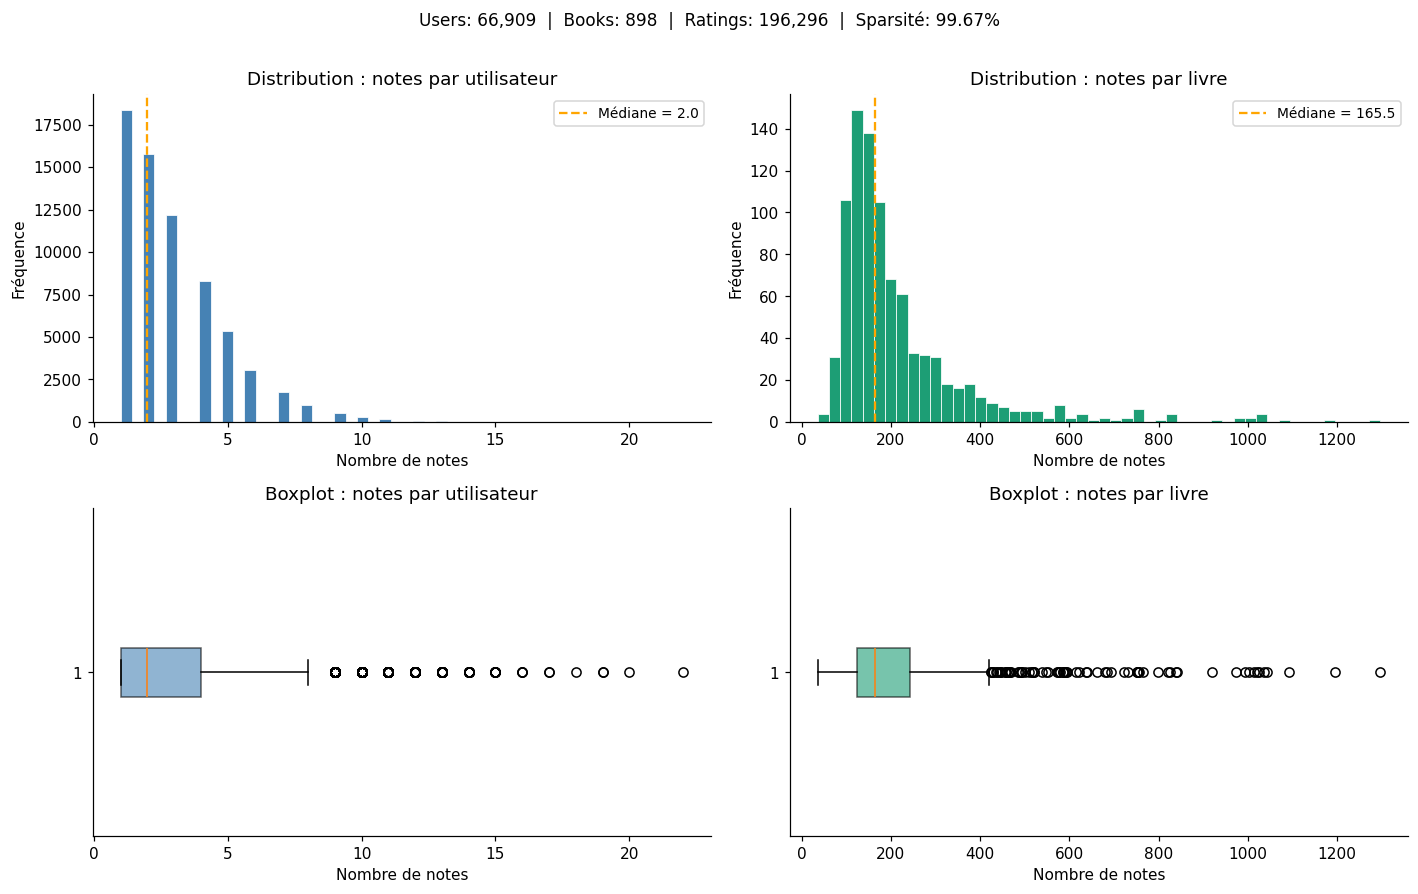

In [10]:
notes_user = ratings.groupby('user_id_mapping').size()
notes_book = ratings.groupby('book_id_mapping').size()

print('Notes par user  → mean:', round(notes_user.mean(), 2),
      '| median:', notes_user.median(),
      '| max:', notes_user.max())
print('Notes par livre → mean:', round(notes_book.mean(), 2),
      '| median:', notes_book.median(),
      '| max:', notes_book.max())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Histogramme users
axes[0, 0].hist(notes_user, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Distribution : notes par utilisateur')
axes[0, 0].set_xlabel('Nombre de notes')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(notes_user.median(), color='orange', linestyle='--', label=f'Médiane = {notes_user.median()}')
axes[0, 0].legend(fontsize=9)

# Histogramme livres
axes[0, 1].hist(notes_book, bins=50, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[0, 1].set_title('Distribution : notes par livre')
axes[0, 1].set_xlabel('Nombre de notes')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(notes_book.median(), color='orange', linestyle='--', label=f'Médiane = {notes_book.median()}')
axes[0, 1].legend(fontsize=9)

# Boxplot users
axes[1, 0].boxplot(notes_user, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1, 0].set_title('Boxplot : notes par utilisateur')
axes[1, 0].set_xlabel('Nombre de notes')

# Boxplot livres
axes[1, 1].boxplot(notes_book, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#1D9E75', alpha=0.6))
axes[1, 1].set_title('Boxplot : notes par livre')
axes[1, 1].set_xlabel('Nombre de notes')

# Statistiques globales
n_users  = ratings['user_id_mapping'].nunique()
n_books  = ratings['book_id_mapping'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_books))

fig.suptitle(
    f'Users: {n_users:,}  |  Books: {n_books:,}  |  Ratings: {n_ratings:,}  |  Sparsité: {sparsity*100:.2f}%',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

**Ce qu'on observe** :

La médiane des notes par utilisateur est très basse (autour de 2), ce qui signifie que la moitié des utilisateurs n'ont noté que 1 ou 2 livres. C'est le problème du cold start : avec si peu d'interactions, il est difficile de construire un profil fiable pour ces utilisateurs.

La sparsité dépasse 99.6% : si on construisait une grille complète utilisateurs x livres, plus de 99 cases sur 100 seraient vides. C'est pour cette raison qu'on utilise une matrice creuse (`csr_matrix`) plutôt qu'un tableau numpy classique.

Les livres présentent une distribution long-tail typique : quelques titres très populaires concentrent une grande partie des notes, tandis que la majorité des livres en ont peu.

### 4.3 Top 10 livres et top 10 utilisateurs les plus actifs
Ces visualisations permettent d'identifier les entités qui dominent le dataset et qui risquent de sur-influencer les recommandations.

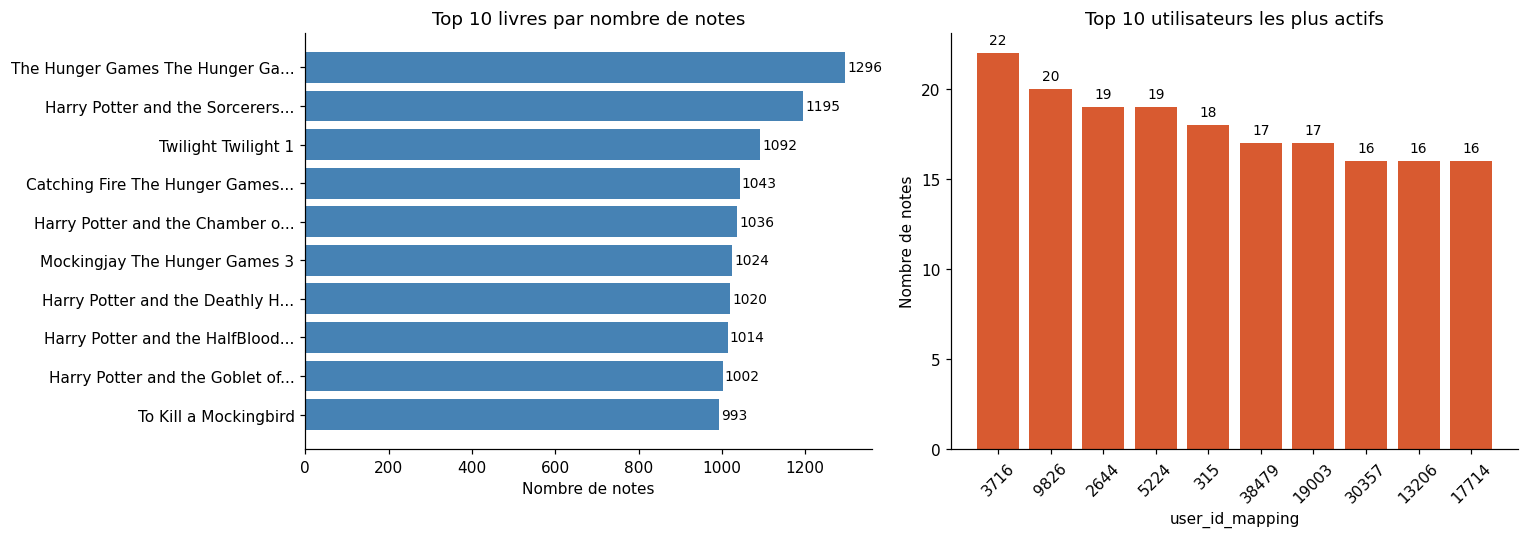

In [11]:
book_lookup_eda = rating_df.groupby('book_id_mapping')['title'].first().reset_index()
ratings_titled  = ratings.merge(book_lookup_eda, on='book_id_mapping', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 livres
top_books = ratings_titled.groupby('title').size().sort_values(ascending=False).head(10)
top_books_short = top_books.copy()
top_books_short.index = [t[:30] + '...' if len(t) > 30 else t for t in top_books.index]
axes[0].barh(top_books_short.index[::-1], top_books_short.values[::-1], color='steelblue')
axes[0].set_title('Top 10 livres par nombre de notes')
axes[0].set_xlabel('Nombre de notes')
for i, v in enumerate(top_books_short.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Top 10 users les plus actifs
top_users = ratings.groupby('user_id_mapping').size().sort_values(ascending=False).head(10)
axes[1].bar([str(u) for u in top_users.index], top_users.values, color='#D85A30')
axes[1].set_title('Top 10 utilisateurs les plus actifs')
axes[1].set_xlabel('user_id_mapping')
axes[1].set_ylabel('Nombre de notes')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(top_users.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Ce qu'on observe** : la distribution long-tail est très marquée. Harry Potter and the Sorcerers.. et Hunger Games dominent largement, et surtout, plusieurs tomes de ces séries apparaissent séparément dans le top 10. Ce phénomène, qu'on peut appeler "effet de série", va créer des similarités artificiellement élevées entre les tomes d'une même série (car les mêmes utilisateurs les ont tous lus). Le modèle risque de recommander "Harry Potter tome 2" à quelqu'un qui vient de noter "Harry Potter tome 1" - ce qui est certes logique mais peut être aussi peu utile en termes de découverte.

### 4.4 Analyse de la note moyenne par livre
Au-delà du nombre de notes, on s'intéresse à leur qualité : quelle est la note moyenne par livre, et à quel point les avis divergent-ils ?

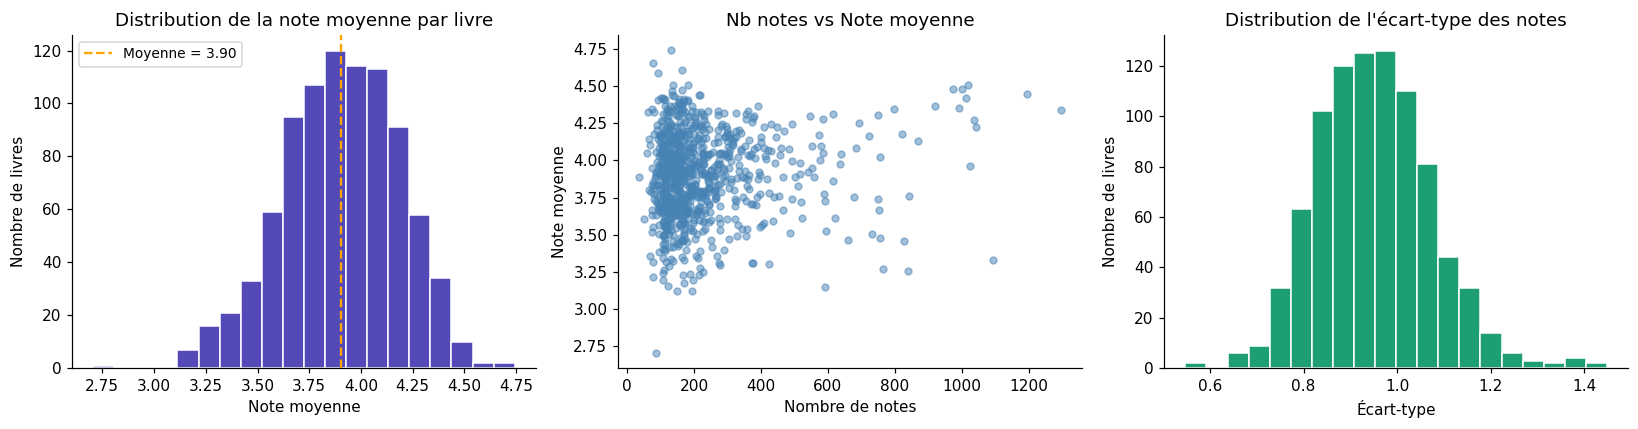


Top 5 livres les mieux notés (min 50 notes) :


,title,nb_notes,note_moy
0,Harry Potter Boxset Harry Potter 17,132,4.74
1,We Should All Be Feminists,78,4.65
2,A Court of Mist and Fury A Court of Thorns and...,164,4.60
3,A Court of Wings and Ruin A Court of Thorns an...,92,4.59
4,Harry Potter and the Deathly Hallows Harry Pot...,1020,4.51


In [12]:
# Note moyenne et nombre de notes par livre
book_stats = ratings_titled.groupby('title').agg(
    nb_notes  = ('rating', 'count'),
    note_moy  = ('rating', 'mean'),
    note_std  = ('rating', 'std')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution des notes moyennes
axes[0].hist(book_stats['note_moy'].dropna(), bins=20, color='#534AB7', edgecolor='white')
axes[0].set_title('Distribution de la note moyenne par livre')
axes[0].set_xlabel('Note moyenne')
axes[0].set_ylabel('Nombre de livres')
axes[0].axvline(book_stats['note_moy'].mean(), color='orange', linestyle='--',
                label=f"Moyenne = {book_stats['note_moy'].mean():.2f}")
axes[0].legend(fontsize=9)

# Scatter : nb_notes vs note_moy
axes[1].scatter(book_stats['nb_notes'], book_stats['note_moy'],
                alpha=0.5, s=20, color='steelblue')
axes[1].set_title('Nb notes vs Note moyenne')
axes[1].set_xlabel('Nombre de notes')
axes[1].set_ylabel('Note moyenne')

# Distribution de l'écart-type des notes
axes[2].hist(book_stats['note_std'].dropna(), bins=20, color='#1D9E75', edgecolor='white')
axes[2].set_title('Distribution de l\'écart-type des notes')
axes[2].set_xlabel('Écart-type')
axes[2].set_ylabel('Nombre de livres')

plt.tight_layout()
plt.show()

print('\nTop 5 livres les mieux notés (min 50 notes) :')
display(book_stats[book_stats['nb_notes'] >= 50]
        .sort_values('note_moy', ascending=False)
        .head(5)[['title', 'nb_notes', 'note_moy']]
        .round(2)
        .reset_index(drop=True))

---
## 5. Préparation des données pour la modélisation

### 5.1 Filtrage - garder les utilisateurs et livres avec suffisamment d'interactions
Avant de construire la matrice, on retire les utilisateurs et les livres qui ont trop peu d'interactions pour être statistiquement utiles.

Le raisonnement : un utilisateur avec une seule note ne crée aucun lien de similarité entre deux livres. Un livre avec très peu de notes a un vecteur trop creux pour que la similarité cosinus soit fiable.

Les seuils retenus sont conservateurs pour ne pas perdre trop de données :
- utilisateurs : au moins 2 notes
- livres : au moins 5 notes

In [13]:
# Filtrage simple (approche initiale — conservée pour référence)
user_counts  = ratings['user_id_mapping'].value_counts()
book_counts  = ratings['book_id_mapping'].value_counts()
min_user_ratings = 2
min_book_ratings = 5

ratings_filt = ratings[
    ratings['user_id_mapping'].isin(user_counts[user_counts >= min_user_ratings].index) &
    ratings['book_id_mapping'].isin(book_counts[book_counts >= min_book_ratings].index)
].copy()

print(f'Avant filtre : {ratings.shape}')
print(f'Après filtre : {ratings_filt.shape}')
print(f'Users  : {ratings_filt["user_id_mapping"].nunique():,}')
print(f'Books  : {ratings_filt["book_id_mapping"].nunique():,}')

n_u2 = ratings_filt['user_id_mapping'].nunique()
n_b2 = ratings_filt['book_id_mapping'].nunique()
spar2 = 1 - (len(ratings_filt) / (n_u2 * n_b2))
print(f'Sparsité après filtre : {spar2*100:.2f}%')

Avant filtre : (196296, 3)
Après filtre : (177916, 3)
Users  : 48,529
Books  : 898
Sparsité après filtre : 99.59%


### 5.2 Visualisation de l'impact du filtrage
On visualise ce que le filtrage retire réellement du dataset.

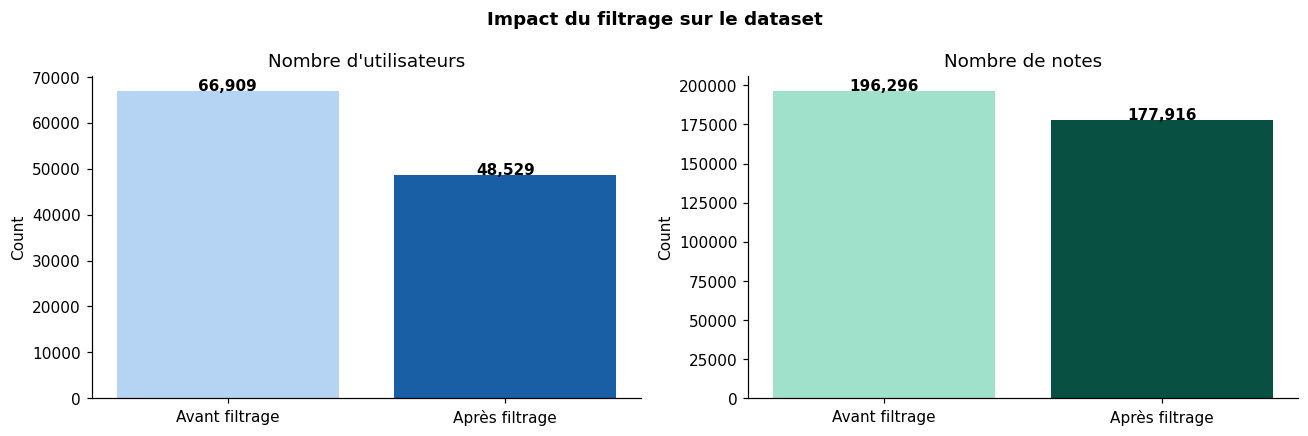

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Avant filtrage', 'Après filtrage']
users_counts_comp  = [ratings['user_id_mapping'].nunique(), ratings_filt['user_id_mapping'].nunique()]
ratings_counts_comp = [len(ratings), len(ratings_filt)]
colors_comp = ['#B5D4F4', '#185FA5']

axes[0].bar(labels, users_counts_comp, color=colors_comp)
axes[0].set_title('Nombre d\'utilisateurs')
axes[0].set_ylabel('Count')
for i, v in enumerate(users_counts_comp):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(labels, ratings_counts_comp, color=['#9FE1CB', '#085041'])
axes[1].set_title('Nombre de notes')
axes[1].set_ylabel('Count')
for i, v in enumerate(ratings_counts_comp):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Impact du filtrage sur le dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Construction de la matrice Item-User (baseline CF)
On prépare les données pour la construction de la matrice creuse. On récupère d'abord les titres via une jointure, puis on visualise les livres les plus présents dans le dataset filtré.

In [15]:
book_lookup = rating_df.groupby('book_id_mapping')['title'].first().reset_index()
ratings_with_title = ratings_filt.merge(book_lookup, on='book_id_mapping', how='left')
print(f'Shape : {ratings_with_title.shape}')
print(f'Titres manquants : {ratings_with_title["title"].isna().sum()}')
display(ratings_with_title.head())

Shape : (177916, 4)
Titres manquants : 0


,user_id_mapping,book_id_mapping,rating,title
0,1537,299,5.0,I Am the Messenger
1,23039,299,3.0,I Am the Messenger
2,39096,299,3.0,I Am the Messenger
3,14631,299,4.0,I Am the Messenger
4,32816,299,5.0,I Am the Messenger


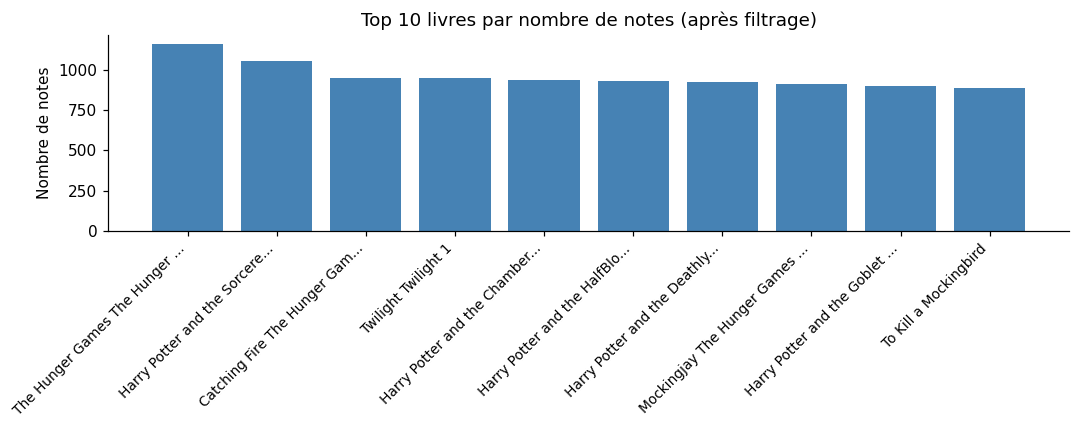

In [16]:
# Top 10 livres par nombre de notes
top_books_filt = ratings_with_title.groupby('title').size().sort_values(ascending=False).head(10)
top_books_short = [t[:28]+'...' if len(t) > 28 else t for t in top_books_filt.index]

plt.figure(figsize=(10, 4))
plt.bar(top_books_short, top_books_filt.values, color='steelblue')
plt.title('Top 10 livres par nombre de notes (après filtrage)')
plt.ylabel('Nombre de notes')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
# Construction de la matrice sparse
unique_users   = ratings_filt['user_id_mapping'].unique()
unique_books   = ratings_filt['book_id_mapping'].unique()
user_to_idx    = {u: i for i, u in enumerate(unique_users)}
book_to_idx    = {b: i for i, b in enumerate(unique_books)}

rows = ratings_filt['book_id_mapping'].map(book_to_idx).values
cols = ratings_filt['user_id_mapping'].map(user_to_idx).values
vals = ratings_filt['rating'].values

item_user_sparse = csr_matrix(
    (vals, (rows, cols)),
    shape=(len(unique_books), len(unique_users))
)

print(f'Item-User sparse shape : {item_user_sparse.shape}')
print(f'Non-zeros              : {item_user_sparse.nnz:,}')

Item-User sparse shape : (898, 48529)
Non-zeros              : 177,916


---
## 6. Modèle Baseline - Item-Item Collaborative Filtering (Cosine)

Cette première approche sert de référence. On calcule directement la similarité cosinus entre tous les livres à partir de leur profil d'utilisateurs dans la matrice creuse.

Le principe : deux livres sont considérés similaires si les mêmes utilisateurs les ont notés de façon comparable. On n'a pas besoin de connaître le contenu des livres pour cela.

In [18]:
item_item_sim = cosine_similarity(item_user_sparse)
print(f'Item-Item similarity shape : {item_item_sim.shape}')
print(f'Exemple ligne 0 (5 premières valeurs) : {item_item_sim[0][:5]}')

Item-Item similarity shape : (898, 898)
Exemple ligne 0 (5 premières valeurs) : [1. 0. 0. 0. 0.]


In [19]:
def recommend_for_user_baseline(user_id, top_n=5):
    """Recommandation item-item cosine (approche baseline)."""
    if user_id not in user_to_idx:
        return 'User inconnu dans le dataset filtré.'
    u_idx        = user_to_idx[user_id]
    user_ratings = item_user_sparse[:, u_idx].toarray().ravel()
    rated_items  = np.where(user_ratings > 0)[0]
    scores       = np.zeros(item_user_sparse.shape[0])
    for b in rated_items:
        scores += item_item_sim[b] * user_ratings[b]
    scores[rated_items] = -1
    top_idx = np.argsort(scores)[::-1][:top_n]
    recs = []
    for idx in top_idx:
        book_id = unique_books[idx]
        title   = book_lookup[book_lookup['book_id_mapping'] == book_id]['title'].iloc[0]
        recs.append((book_id, title, round(scores[idx], 4)))
    return recs

# Test
example_user = unique_users[0]
print(f'Recommandations baseline pour user {example_user} :')
for bid, title, score in recommend_for_user_baseline(example_user, top_n=5):
    print(f'  {score:.4f}  {title}')

print('\nTest cold start :')
print(recommend_for_user_baseline(999999999, top_n=5))

Recommandations baseline pour user 1537 :
  0.5973  Delirium Delirium 1
  0.4898  A Darker Shade of Magic Shades of Magic 1
  0.4604  The Sea of Monsters Percy Jackson and the Olympians 2
  0.4500  Fire Graceling Realm 2
  0.4337  The Hunger Games The Hunger Games 1

Test cold start :
User inconnu dans le dataset filtré.


**Limites identifiées sur ce modèle baseline** :

La matrice de similarité produite est dense (898 x 898 valeurs stockées), ce qui ne passe pas à l'échelle sur de grands catalogues.

Les notes basses (1-2) sont traitées comme du signal positif dans le calcul des scores : un livre noté 1 contribue positivement aux recommandations, ce qui n'a pas de sens.

Aucune gestion du cold start : un utilisateur inconnu ne reçoit rien.

Pas de pondération : un utilisateur très actif (500 notes) influence autant qu'un utilisateur normal (2 notes).

Ces quatre problèmes motivent le passage au modèle ALS dans la section suivante.

## 7. Modèle Amélioré  ALS Implicite avec Pondération BM25

ALS est une méthode de factorisation matricielle adaptée aux données implicites comme dans notre projet ici les like. Elle représente chaque utilisateur et chaque livre par un vecteur dense appelé embedding latent.

### 7.1 Prétraitement amélioré : binarisation et filtrage k-core

Deux améliorations importantes par rapport à la baseline :

**Binarisation** : on sépare les notes positives (>= 4) des notes négatives (<= 2). ALS travaille sur des données implicites - on lui dit "cet utilisateur a apprécié ce livre", pas "il lui a donné 4.5". Les notes négatives sont mémorisées à part pour filtrer les recommandations en fin de pipeline.

**Filtrage k-core** : contrairement au filtrage simple appliqué une seule fois, le k-core répète le filtrage jusqu'à convergence. Après avoir retiré des livres rares, certains utilisateurs peuvent se retrouver sous le seuil minimum, ce qui nécessite un nouveau tour. On itère jusqu'à ce que plus rien ne change.

In [20]:
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight

def kcore_filter(df, user_col, item_col, min_u=3, min_i=5, max_iter=10):
    """
    Filtrage itératif k-core : garantit que chaque user a >= min_u interactions
    et chaque item >= min_i interactions — de façon simultanée et convergente.
    """
    for _ in range(max_iter):
        n  = len(df)
        uc = df[user_col].value_counts()
        ic = df[item_col].value_counts()
        df = df[
            df[user_col].isin(uc[uc >= min_u].index) &
            df[item_col].isin(ic[ic >= min_i].index)
        ]
        if len(df) == n:
            break  # convergé
    return df.copy()

# Séparation likes / dislikes
likes    = rating_df[rating_df['rating'] >= 4].copy()
dislikes = rating_df[rating_df['rating'] <= 2][['user_id_mapping', 'book_id_mapping']]
dislikes_set = set(zip(dislikes['user_id_mapping'], dislikes['book_id_mapping']))

# Filtrage k-core sur les likes uniquement
likes_filt = kcore_filter(likes, 'user_id_mapping', 'book_id_mapping')

print(f'Likes après k-core :')
print(f'  Lignes  : {len(likes_filt):,}')
print(f'  Users   : {likes_filt["user_id_mapping"].nunique():,}')
print(f'  Livres  : {likes_filt["book_id_mapping"].nunique():,}')

Likes après k-core :
  Lignes  : 81,713
  Users   : 20,594
  Livres  : 898


**Nous avons utilisé le k-core plutôt qu'un simple filtre** parce que par exemple un utilisateur A qui a noté 3 livres : X, Y et Z. Si on retire Z (trop rare), A n'a plus que 2 notes. Si le seuil minimum est 3, A devrait être retiré à son tour. Le filtre simple ne verrait pas ce cas. Le k-core le corrige en refaisant un passage.

### 7.2 Construction de la matrice et pondération BM25
Dans la présente étude, nous avons utilisé la pondération BM25 (issue de la recherche d'information) pour atténuer l'influence des utilisateurs très actifs. Sans pondération, un utilisateur qui a noté 500 livres dominerait les similarités calculées. BM25 réduit ce déséquilibre.

In [21]:
unique_users = likes_filt['user_id_mapping'].unique()
unique_books = likes_filt['book_id_mapping'].unique()
user2idx     = {u: i for i, u in enumerate(unique_users)}
book2idx     = {b: i for i, b in enumerate(unique_books)}
idx2book     = {i: b for b, i in book2idx.items()}

rows = likes_filt['book_id_mapping'].map(book2idx).values
cols = likes_filt['user_id_mapping'].map(user2idx).values
vals = likes_filt['rating'].values.astype(np.float32)

item_user = csr_matrix(
    (vals, (rows, cols)),
    shape=(len(unique_books), len(unique_users))
)

# Pondération BM25 : atténue l'influence des super-users
item_user_weighted = bm25_weight(item_user, K1=100, B=0.8).tocsr()

print(f'Matrice item×user : {item_user.shape}')
print(f'Non-zeros         : {item_user.nnz:,}')

Matrice item×user : (898, 20594)
Non-zeros         : 81,713


### 7.3 Entraînement du modèle ALS
On entraîne le modèle avec 128 dimensions latentes sur 30 itérations. Chaque livre et chaque utilisateur sera représenté par un vecteur de 128 nombres après l'entraînement.

In [23]:
model = AlternatingLeastSquares(
    factors       = 128,    # dimension des embeddings latents
    regularization= 0.1,   # régularisation L2 (évite l'overfitting)
    iterations    = 30,     # nombre de cycles d'alternance
    use_gpu       = False,
    random_state  = 42
)
model.fit(item_user_weighted)
print('Modèle ALS entraîné ')
print(f'item_factors shape : {model.item_factors.shape}')
print(f'user_factors shape : {model.user_factors.shape}')

  0%|          | 0/30 [00:00<?, ?it/s]

Modèle ALS entraîné 
item_factors shape : (20594, 128)
user_factors shape : (898, 128)


**Comment fonctionne ALS ?** Le modèle cherche à décomposer la matrice utilisateurs-livres en deux matrices plus petites : une pour les utilisateurs, une pour les livres. Avec le modèle, on optimise une matrice à la fois en fixant l'autre. Quand les vecteurs utilisateurs sont fixés, trouver les meilleurs vecteurs livres revient à résoudre une régression linéaire. On alterne jusqu'à convergence.

### 7.4 Visualisation des embeddings ALS — Distribution des valeurs
On examine la structure des embeddings produits : distribution des valeurs et normes des vecteurs. La norme d'un embedding livre donne une idée de la "confiance" du modèle pour ce livre - les livres bien représentés ont des normes plus élevées.

Embeddings livres : (898, 128)  (doit être (898, 128))


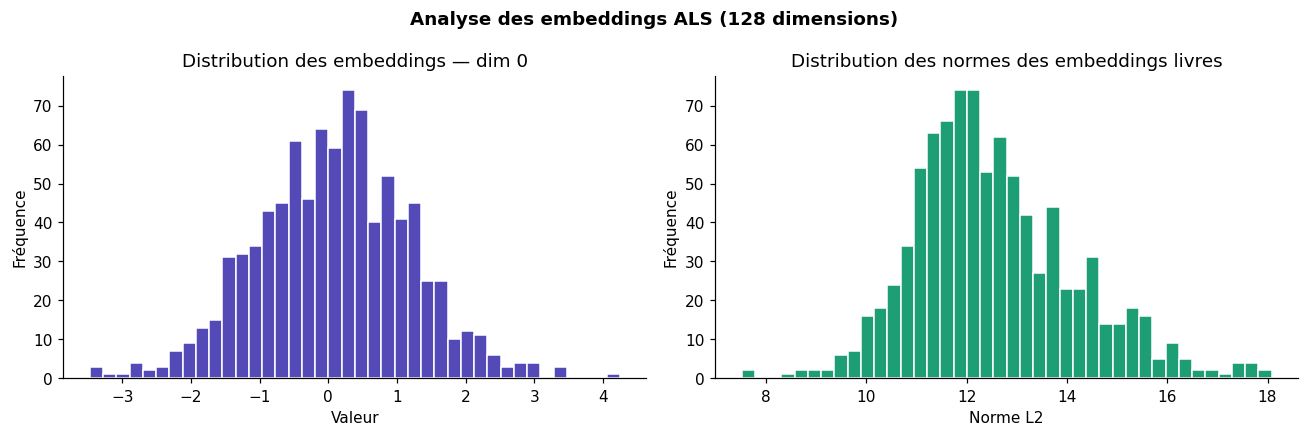


Norme moyenne : 12.5457
Norme min/max : 7.5128 / 18.0787


In [24]:
# Dans implicit 0.7.2 : user_factors = embeddings des livres (898), item_factors = users (20594)
# On vérifie et on prend le bon
if model.user_factors.shape[0] == len(unique_books):
    item_emb = model.user_factors
else:
    item_emb = model.item_factors

print(f'Embeddings livres : {item_emb.shape}  (doit être ({len(unique_books)}, 128))')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des valeurs de la première dimension
axes[0].hist(item_emb[:, 0], bins=40, color='#534AB7', edgecolor='white')
axes[0].set_title('Distribution des embeddings — dim 0')
axes[0].set_xlabel('Valeur')
axes[0].set_ylabel('Fréquence')

# Norme des vecteurs (mesure de la "confiance" du modèle pour chaque livre)
norms = np.linalg.norm(item_emb, axis=1)
axes[1].hist(norms, bins=40, color='#1D9E75', edgecolor='white')
axes[1].set_title('Distribution des normes des embeddings livres')
axes[1].set_xlabel('Norme L2')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Analyse des embeddings ALS (128 dimensions)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nNorme moyenne : {norms.mean():.4f}')
print(f'Norme min/max : {norms.min():.4f} / {norms.max():.4f}')

### 7.5 Fonction de recommandation ALS

La fonction `recommend_for_user` intègre deux améliorations par rapport à la baseline :
- **Gestion du cold start** : si l'utilisateur est inconnu, on lui propose les livres les plus populaires
- **Filtrage des dislikes** : les livres notés 1-2 par cet utilisateur sont exclus des recommandations

In [25]:
user_items = item_user.T.tocsr()  # (n_users × n_books)

def _get_title(book_id):
    row = book_lookup[book_lookup['book_id_mapping'] == book_id]
    return row['title'].iloc[0] if len(row) > 0 else f'book_{book_id}'

def recommend_for_user(user_id, top_n=10, filter_dislikes=True):
    """Recommandation ALS avec gestion cold start et filtrage des dislikes."""
    # Cold start : user inconnu → popularité
    if user_id not in user2idx:
        popular = likes_filt.groupby('book_id_mapping').size() \
                            .sort_values(ascending=False).head(top_n)
        return [(bid, _get_title(bid), 'popular') for bid in popular.index]

    u_idx = user2idx[user_id]
    item_ids, scores = model.recommend(
        u_idx,
        user_items[u_idx],
        N=top_n * 2,
        filter_already_liked_items=True
    )

    results = []
    for iid, score in zip(item_ids, scores):
        book_id = idx2book[iid]
        if filter_dislikes and (user_id, book_id) in dislikes_set:
            continue
        results.append((book_id, _get_title(book_id), round(float(score), 4)))
        if len(results) == top_n:
            break
    return results

# Test
example_user = unique_users[0]
recs = recommend_for_user(example_user, top_n=5)
print(f'Recommandations ALS pour user {example_user} :')
for bid, title, score in recs:
    print(f'  {score:.4f}  {title}')

print('\nTest cold start (user inconnu) :')
recs_cold = recommend_for_user(999999999, top_n=5)
for bid, title, score in recs_cold:
    print(f'  [{score}]  {title}')

Recommandations ALS pour user 1537 :
  0.9149  The Paris Wife
  0.8870  Saga Vol 1 Saga 1
  0.8868  Betrayed House of Night 2
  0.8822  Robinson Crusoe
  0.8806  We Should All Be Feminists

Test cold start (user inconnu) :
  [popular]  The Hunger Games The Hunger Games 1
  [popular]  Harry Potter and the Sorcerers Stone Harry Potter 1
  [popular]  Harry Potter and the Deathly Hallows Harry Potter 7
  [popular]  Harry Potter and the HalfBlood Prince Harry Potter 6
  [popular]  Harry Potter and the Goblet of Fire Harry Potter 4


---
## 8. Clustering sur les Embeddings ALS

Les embeddings ALS produits à l'étape précédente capturent une représentation latente de chaque livre. On peut les utiliser pour regrouper les livres en clusters selon leur proximité dans cet espace.

Deux intérêts principaux :
- Réduire l'espace de recherche lors d'une recommandation : plutôt que comparer un livre aux 898 autres, on le compare aux ~150 livres de son cluster
- Identifier la structure thématique implicite apprise par ALS

### 8.1 Préparation des embeddings

In [26]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Récupérer les embeddings livres appris par ALS
# Dans implicit 0.7.2 les axes sont inversés — on vérifie lequel correspond aux livres
if model.user_factors.shape[0] == len(unique_books):
    item_embeddings = model.user_factors
else:
    item_embeddings = model.item_factors

# Normalisation L2 : chaque vecteur a une longueur = 1
# Cela permet d'utiliser le produit scalaire comme similarité cosine directement
item_embeddings_norm = normalize(item_embeddings)

print(f'Embeddings livres : {item_embeddings_norm.shape}')
print(f'unique_books      : {len(unique_books)}')

Embeddings livres : (898, 128)
unique_books      : 898


### 8.2 Méthode du coude - choisir K
Pour K-Means, il faut choisir K à l'avance. La méthode du coude trace l'inertie intra-cluster en fonction de K et on cherche le point où le gain diminue nettement.


C:\Users\fallo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\fallo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
C:\Users\fallo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\fallo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, wh

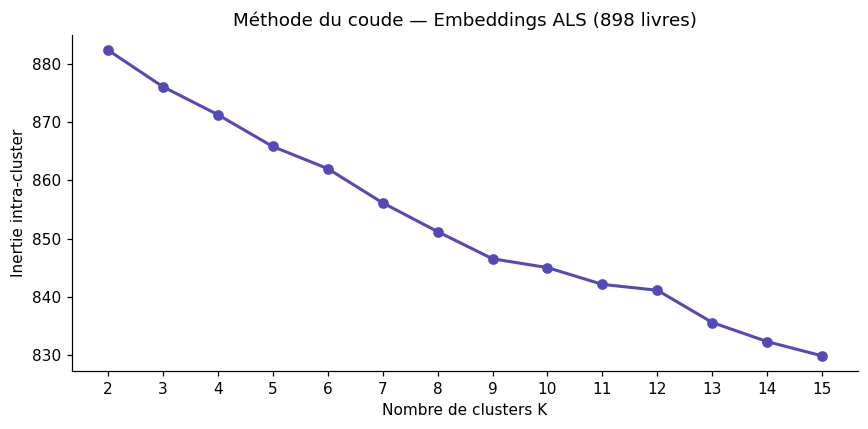

In [27]:
# La méthode du coude permet de choisir K en cherchant
# le point où diminuer K supplémentaire apporte peu de gain
inertias = []
K_range  = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(item_embeddings_norm)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='#534AB7', linewidth=2, markersize=6)
plt.title('Méthode du coude — Embeddings ALS (898 livres)')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie intra-cluster')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

Interprétation : La courbe quasi-linéaire indique l'absence de structure en clusters naturelle dans les embeddings ALS. Cela est dû à la sparsité extrême du dataset (99.6%) - avec peu d'interactions par utilisateur, les embeddings appris sont peu différenciés. On choisit K=10 par règle empirique (compromis lisibilité / granularité).

### 8.3 K-Means sur les embeddings ALS

In [28]:
# K=10 choisi par règle empirique sqrt(n/2) ≈ 21, arrondi pour la lisibilité
# L'absence de coude est une information en soi sur la structure des données
K_OPTIMAL = 10

kmeans_als     = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = kmeans_als.fit_predict(item_embeddings_norm)

# Associer chaque livre à son cluster via idx2book (source de vérité ALS)
books_clustered = pd.DataFrame({
    'book_id_mapping': [idx2book[i] for i in range(len(unique_books))],
    'cluster'        : cluster_labels
})
books_clustered = books_clustered.merge(book_lookup, on='book_id_mapping', how='left')

print(f'Distribution par cluster (K={K_OPTIMAL}) :')
dist = books_clustered['cluster'].value_counts().sort_index()
print(dist)
print(f'\nTaille moy. : {dist.mean():.0f} | min : {dist.min()} | max : {dist.max()}')

C:\Users\fallo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Distribution par cluster (K=10) :
cluster
0     71
1    106
2     63
3    105
4    120
5     83
6     38
7    134
8    104
9     74
Name: count, dtype: int64

Taille moy. : 90 | min : 38 | max : 134


Interprétation : K-Means partitionne les 898 livres en 10 groupes selon la proximité de leurs embeddings. Deux livres dans le même cluster ont été aimés par des profils d'utilisateurs similaires - pas nécessairement le même genre, mais le même type de lecteur.

### 8.4 Visualisation des clusters - PCA 2D
Les embeddings sont en 128 dimensions - impossibles à visualiser directement. On utilise PCA pour les projeter en 2D. La variance expliquée indique combien d'information est conservée dans la projection.

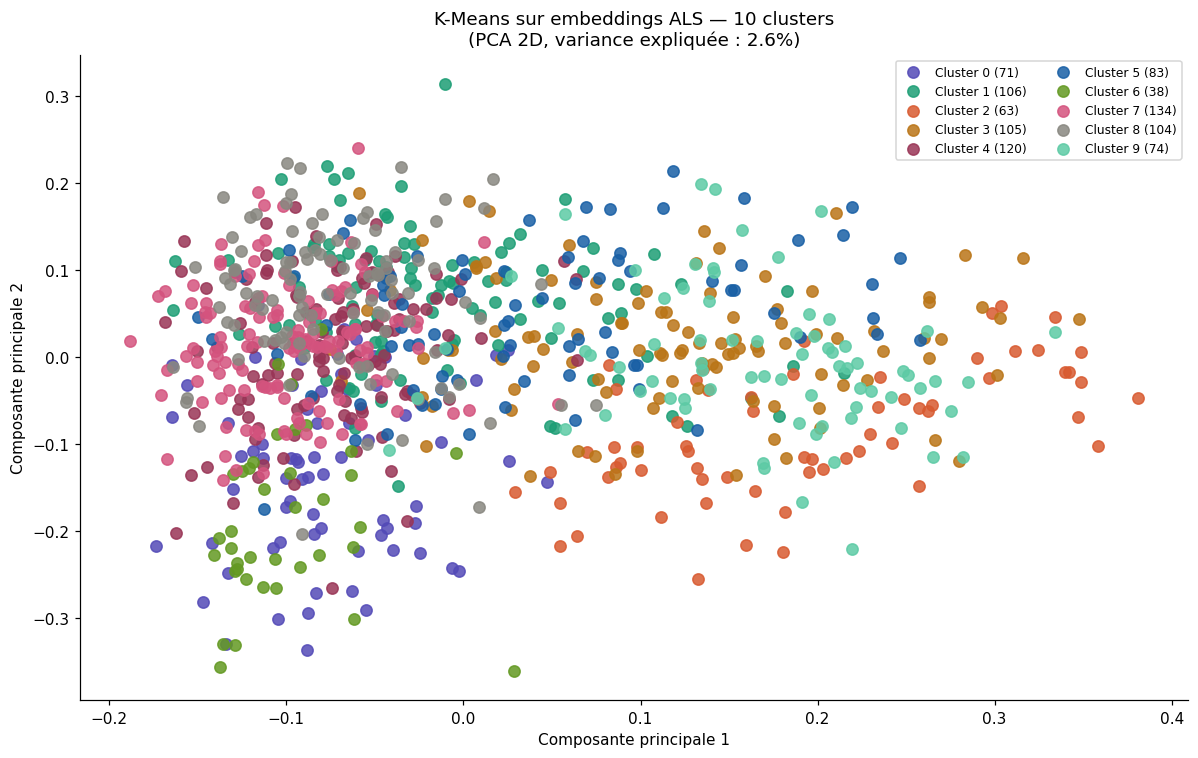

In [29]:
# PCA réduit les 128 dimensions à 2 pour la visualisation
# La variance expliquée va nous indiquer combien d'information est conservée
pca    = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(item_embeddings_norm)
var_exp = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(11, 7))
colors = ['#534AB7','#1D9E75','#D85A30','#BA7517','#993556','#185FA5',
          '#639922','#D4537E','#888780','#5DCAA5']

for c in range(K_OPTIMAL):
    mask = cluster_labels == c
    plt.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=colors[c % len(colors)],
        label=f'Cluster {c} ({mask.sum()})',
        s=55, alpha=0.85
    )

plt.title(f'K-Means sur embeddings ALS — {K_OPTIMAL} clusters\n(PCA 2D, variance expliquée : {var_exp:.1%})')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Interprétation : La projection 2D montre la répartition des livres dans l'espace latent ALS. Des clusters qui se chevauchent visuellement confirment l'absence de frontières nettes - cohérent avec la courbe du coude linéaire.

### 8.5 Aperçu des livres par cluster

On examine quels livres se retrouvent dans chaque cluster pour interpréter ce que chaque groupe représente.

In [30]:
# Afficher le contenu de chaque cluster pour l'interpréter 
print(f'Aperçu des livres par cluster (K-Means ALS, K={K_OPTIMAL}) :\n')
for c in range(K_OPTIMAL):
    livres = books_clustered[books_clustered['cluster'] == c]['title'].dropna().tolist()
    print(f'Cluster {c} ({len(livres)} livres) :')
    for t in livres[:6]:
        print(f'   {t}')
    if len(livres) > 6:
        print(f'   ... +{len(livres)-6} autres')
    print()

Aperçu des livres par cluster (K-Means ALS, K=10) :

Cluster 0 (71 livres) :
   The Name of the Wind The Kingkiller Chronicle 1
   Good Omens The Nice and Accurate Prophecies of Agnes Nutter Witch
   The Andromeda Strain
   The Eye of the World Wheel of Time 1
   Watchmen
   A Wizard of Earthsea Earthsea Cycle 1
   ... +65 autres

Cluster 1 (106 livres) :
   I Am the Messenger
   Unbroken A World War II Story of Survival Resilience and Redemption
   The Five People You Meet in Heaven
   Lean In Women Work and the Will to Lead
   Angelfall Penryn the End of Days 1
   Sharp Objects
   ... +100 autres

Cluster 2 (63 livres) :
   From Dead to Worse Sookie Stackhouse 8
   Slammed Slammed 1
   The Coincidence of Callie Kayden The Coincidence 1
   Faefever Fever 3
   Dead as a Doornail Sookie Stackhouse 5
   Maybe Someday Maybe 1
   ... +57 autres

Cluster 3 (105 livres) :
   Shiver The Wolves of Mercy Falls 1
   Pretty Little Liars Pretty Little Liars 1
   The Darkest Minds The Darkest Minds

Interprétation : L'inspection manuelle des clusters permet de valider qualitativement leur cohérence. Si des livres du même genre ou de la même série se retrouvent ensemble, le modèle a capturé une structure pertinente malgré la sparsité.

### 8.6 Clustering Hiérarchique - Dendrogramme
En complément de K-Means (qui impose un nombre de clusters fixe), le clustering hiérarchique construit une arborescence de regroupements sans paramètre K. Le dendrogramme nous permet ici de visualiser à quelle distance les groupes fusionnent entre eux.

Distribution clusters hiérarchiques (K=10) :
cluster_agglo
0    102
1    183
2    209
3    111
4     40
5     34
6     42
7     30
8    124
9     23
Name: count, dtype: int64


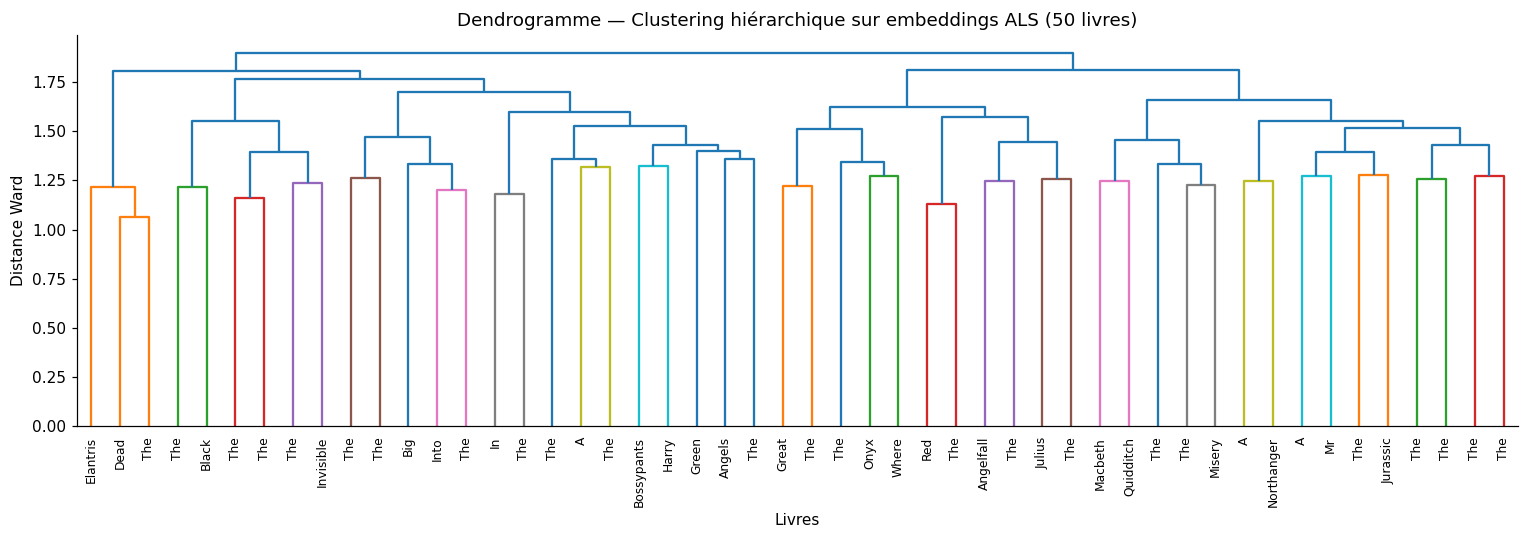

In [31]:
# Le clustering hiérarchique n'a pas besoin de spécifier K à l'avance
# Il construit un arbre de fusion qu'on peut couper à n'importe quel niveau
agglo_als = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
books_clustered['cluster_agglo'] = agglo_als.fit_predict(item_embeddings_norm)

print(f'Distribution clusters hiérarchiques (K={K_OPTIMAL}) :')
print(books_clustered['cluster_agglo'].value_counts().sort_index())

# Dendrogramme sur 50 livres échantillonnés pour la lisibilité
rng        = np.random.RandomState(42)
idx_sample = rng.choice(len(item_embeddings_norm), 50, replace=False)
sample_emb = item_embeddings_norm[idx_sample]
sample_titles = [
    str(books_clustered.iloc[i]['title']).split()[0]
    for i in idx_sample
]

Z = linkage(sample_emb, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(
    Z,
    labels          = sample_titles,
    leaf_rotation   = 90,
    leaf_font_size  = 8,
    color_threshold = 0.7 * max(Z[:, 2])
)
plt.title('Dendrogramme — Clustering hiérarchique sur embeddings ALS (50 livres)')
plt.xlabel('Livres')
plt.ylabel('Distance Ward')
plt.tight_layout()
plt.show()

**Lecture du dendrogramme** : deux livres proches en bas partagent un profil d'utilisateurs très similaire. Plus la jonction est haute, plus les groupes sont dissimilaires. On peut choisir le nombre de clusters en coupant horizontalement le dendrogramme à la hauteur souhaitée.

### 8.7 Recommandation par cluster ALS (Fonction recommandation livre->livres)

In [32]:
def recommander_par_cluster_als(titre_query, top_n=5):
    """
    Entrée  : titre d'un livre (str)
    Sortie  : livres similaires dans le même cluster ALS

    Avantage : compare uniquement ~90 livres du cluster
               au lieu des 898 livres complets
    """
    masque = books_clustered['title'].str.lower().str.contains(
        titre_query.lower(), na=False
    )
    if not masque.any():
        print(f"Titre '{titre_query}' introuvable.")
        return pd.DataFrame()

    idx_local   = masque.idxmax()
    cluster_id  = books_clustered.loc[idx_local, 'cluster']
    titre_exact = books_clustered.loc[idx_local, 'title']

    membres = books_clustered[
        (books_clustered['cluster'] == cluster_id) &
        (books_clustered.index != idx_local)
    ]

    print(f'Livre    : {titre_exact}')
    print(f'Cluster  : {cluster_id}  ({len(membres)+1} livres dans ce cluster)')

    if membres.empty:
        print('Cluster trop petit.')
        return pd.DataFrame()

    # Similarité cosine directement sur item_embeddings_norm (sans SVD)
    vecteur_query   = item_embeddings_norm[idx_local]
    indices_membres = membres.index.tolist()
    similarites     = item_embeddings_norm[indices_membres] @ vecteur_query

    top_idx = np.argsort(similarites)[::-1][:top_n]

    return pd.DataFrame({
        'titre'         : [membres.iloc[i]['title'] for i in top_idx],
        'cluster'       : cluster_id,
        'similarite_als': [round(float(similarites[i]), 4) for i in top_idx]
    })

# Tests
print('=' * 55)
print('RECOMMANDATIONS PAR CLUSTER ALS')
print('=' * 55)
for titre_test in ['Harry Potter', 'Hunger Games', 'Twilight']:
    recs = recommander_par_cluster_als(titre_test, top_n=5)
    if isinstance(recs, pd.DataFrame) and not recs.empty:
        display(recs)
    print()

RECOMMANDATIONS PAR CLUSTER ALS
Livre    : Harry Potter Boxset Harry Potter 17
Cluster  : 3  (105 livres dans ce cluster)


,titre,cluster,similarite_als
0,Is Everyone Hanging Out Without Me,3,0.1807
1,Ugly Love,3,0.1529
2,Harry Potter and the Prisoner of Azkaban Harry...,3,0.1396
3,Stargirl Stargirl 1,3,0.1338
4,Pride and Prejudice and Zombies Pride and Prej...,3,0.1335



Livre    : Mockingjay The Hunger Games 3
Cluster  : 5  (83 livres dans ce cluster)


,titre,cluster,similarite_als
0,Quidditch Through the Ages,5,0.2080
1,Message in a Bottle,5,0.2059
2,World War Z An Oral History of the Zombie War,5,0.1759
3,The Brief Wondrous Life of Oscar Wao,5,0.1508
4,Walk Two Moons,5,0.1410



Livre    : The Short Second Life of Bree Tanner Twilight 35
Cluster  : 2  (63 livres dans ce cluster)


,titre,cluster,similarite_als
0,Walking Disaster Beautiful 2,2,0.3675
1,Fifty Shades Freed Fifty Shades 3,2,0.3568
2,Circus of the Damned Anita Blake Vampire Hunter 3,2,0.2899
3,Beautiful Disaster Beautiful 1,2,0.2831
4,Blood Promise Vampire Academy 4,2,0.2495


### 8.8 Recommandation par cluster ALS (Fonction recommandation user->livres)

In [33]:
def recommander_user_par_cluster_als(user_id, top_n=10, filter_dislikes=True):
    """
    Entrée  : un user_id
    Sortie  : livres recommandés basés sur les patterns comportementaux

    Mécanisme :
    1. Trouver les livres déjà likés par le user
    2. Identifier les clusters dominants de ces livres
    3. Chercher les candidats uniquement dans ces clusters
    4. Scorer par similarité cosine vecteur user ↔ vecteurs livres
    """

    # Cold start : user inconnu → fallback popularité
    if user_id not in user2idx:
        print(f"User {user_id} inconnu → fallback popularité")
        popular = likes_filt.groupby('book_id_mapping').size() \
                            .sort_values(ascending=False).head(top_n)
        return pd.DataFrame({
            'titre'  : [_get_title(bid) for bid in popular.index],
            'cluster': 'N/A',
            'score'  : 'popular'
        })

    u_idx = user2idx[user_id]

    # 1. Livres likés par le user
    liked_indices  = item_user[:, u_idx].nonzero()[0].tolist()

    if not liked_indices:
        print(f"User {user_id} sans historique → fallback popularité")
        popular = likes_filt.groupby('book_id_mapping').size() \
                            .sort_values(ascending=False).head(top_n)
        return pd.DataFrame({
            'titre'  : [_get_title(bid) for bid in popular.index],
            'cluster': 'N/A',
            'score'  : 'popular'
        })

    liked_book_ids = [idx2book[i] for i in liked_indices]

    # 2. Clusters dominants des livres likés
    liked_clusters = books_clustered[
        books_clustered['book_id_mapping'].isin(liked_book_ids)
    ]['cluster'].value_counts()
    top_clusters = liked_clusters.head(2).index.tolist()

    print(f"User               : {user_id}")
    print(f"Livres likés       : {len(liked_book_ids)}")
    print(f"Clusters dominants : {top_clusters}")

    # 3. Candidats dans ces clusters, non encore likés
    candidats = books_clustered[
        (books_clustered['cluster'].isin(top_clusters)) &
        (~books_clustered['book_id_mapping'].isin(liked_book_ids))
    ].copy()

    if candidats.empty:
        print("Pas assez de candidats dans les clusters.")
        return pd.DataFrame()

    # 4. Vecteur user ALS (sans SVD)
    if model.user_factors.shape[0] == len(unique_books):
        u_vec = model.item_factors[u_idx]
    else:
        u_vec = model.user_factors[u_idx]

    u_vec = u_vec / (np.linalg.norm(u_vec) + 1e-9)  # normalisation

    # Similarité cosine user ↔ livres candidats
    indices_candidats  = candidats.index.tolist()
    vecteurs_candidats = item_embeddings_norm[indices_candidats]
    scores             = vecteurs_candidats @ u_vec

    top_idx = np.argsort(scores)[::-1][:top_n * 2]

    results = []
    for i in top_idx:
        book_id = candidats.iloc[i]['book_id_mapping']
        cluster = candidats.iloc[i]['cluster']
        if filter_dislikes and (user_id, book_id) in dislikes_set:
            continue
        results.append({
            'titre'  : _get_title(book_id),
            'cluster': int(cluster),
            'score'  : round(float(scores[i]), 4)
        })
        if len(results) == top_n:
            break

    return pd.DataFrame(results)

# Tests
test_users = likes_filt['user_id_mapping'].unique()[:3]

print('=' * 60)
print('RECOMMANDATIONS USER PAR CLUSTER ALS')
print('Basées sur les patterns comportementaux des utilisateurs')
print('=' * 60)

for test_user in test_users:
    print(f'\n{"─"*60}')
    recs = recommander_user_par_cluster_als(test_user, top_n=5)
    if isinstance(recs, pd.DataFrame) and not recs.empty:
        display(recs)

RECOMMANDATIONS USER PAR CLUSTER ALS
Basées sur les patterns comportementaux des utilisateurs

────────────────────────────────────────────────────────────
User               : 1537
Livres likés       : 8
Clusters dominants : [1, 6]


,titre,cluster,score
0,Pet Sematary,6,0.2943
1,An Abundance of Katherines,1,0.2083
2,The Waste Lands,6,0.1939
3,The Secret Life of Bees,1,0.1883
4,In Her Shoes,6,0.1749



────────────────────────────────────────────────────────────
User               : 14631
Livres likés       : 3
Clusters dominants : [1, 7]


,titre,cluster,score
0,The Book Thief,1,0.2597
1,Guns Germs and Steel The Fates of Human Societies,7,0.2409
2,The Memory Keepers Daughter,1,0.2138
3,Julius Caesar,1,0.1993
4,Enders Game Enders Saga 1,7,0.1961



────────────────────────────────────────────────────────────
User               : 32816
Livres likés       : 3
Clusters dominants : [1, 3]


,titre,cluster,score
0,Days of Blood Starlight Daughter of Smoke Bone 2,3,0.2707
1,Across the Universe Across the Universe 1,3,0.2631
2,Untamed House of Night 4,3,0.2334
3,The Heir The Selection 4,3,0.2264
4,Hex Hall Hex Hall 1,3,0.2066


---
## 9. Modèle Content-Based - Filtrage par Contenu - TF-IDF
 

Contrairement au filtrage collaboratif qui utilise les notes des utilisateurs, cette approche compare les livres entre eux sur la base de leur texte : description et genre. Elle est totalement indépendante des comportements utilisateurs.

Avantage principal : elle fonctionne pour n'importe quel livre ayant une description, même sans aucune note.

### 9.1 Couverture des métadonnées

On vérifie d'abord combien de livres du dataset de notes ont des métadonnées disponibles.



In [34]:
common = set(rating_df['book_id_mapping']).intersection(set(metadata['book_id_mapping']))
print(f'Livres communs rating_df ∩ metadata : {len(common)}')
print(f'Livres uniques rating_df            : {rating_df["book_id_mapping"].nunique()}')
print(f'Livres uniques metadata             : {metadata["book_id_mapping"].nunique()}')
print(f'\nCouverture : {len(common)/rating_df["book_id_mapping"].nunique()*100:.1f}% des livres CF ont des métadonnées')

Livres communs rating_df ∩ metadata : 95
Livres uniques rating_df            : 898
Livres uniques metadata             : 96

Couverture : 10.6% des livres CF ont des métadonnées


**Limite importante** : seulement 96 livres sur 898 ont des métadonnées textuelles, soit environ 10%. Le pipeline content-based ne s'applique qu'à ce sous-ensemble. Pour un déploiement réel, il nous faudrait enrichir davantage ce fichier.

### 9.2 Préparation du texte et analyse univariée du corpus

On construit un champ texte composite pour chaque livre en concaténant le titre, les genres nettoyés et la description. Ce texte sera la base de la vectorisation TF-IDF.

Le nettoyage des genres est nécessaire car ils sont stockés sous forme de chaîne imitant une liste Python : `"['fantasy, paranormal', 'fiction']"`. On retire les crochets, guillemets et virgules pour obtenir une suite de mots séparés par des espaces.

In [35]:
tfidf_books = metadata.copy()

# Nettoyage des genres
tfidf_books['genre_clean'] = (
    tfidf_books['genre'].astype(str)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace("'", '', regex=False)
    .str.replace(',', ' ', regex=False)
    .str.lower().str.strip()
)

# Construction du champ texte combiné
tfidf_books['text'] = (
    tfidf_books['title'].astype(str).str.lower().str.strip() + ' ' +
    tfidf_books['genre_clean'].fillna('') + ' ' +
    tfidf_books['description'].astype(str).str.lower().str.strip()
).str.strip()

tfidf_books['text_len'] = tfidf_books['text'].str.len()

print(f'Min: {tfidf_books["text_len"].min()} | Median: {tfidf_books["text_len"].median()} | Max: {tfidf_books["text_len"].max()}')
print(f'Textes vides: {(tfidf_books["text_len"] == 0).sum()}')

Min: 291 | Median: 879.5 | Max: 2342
Textes vides: 0


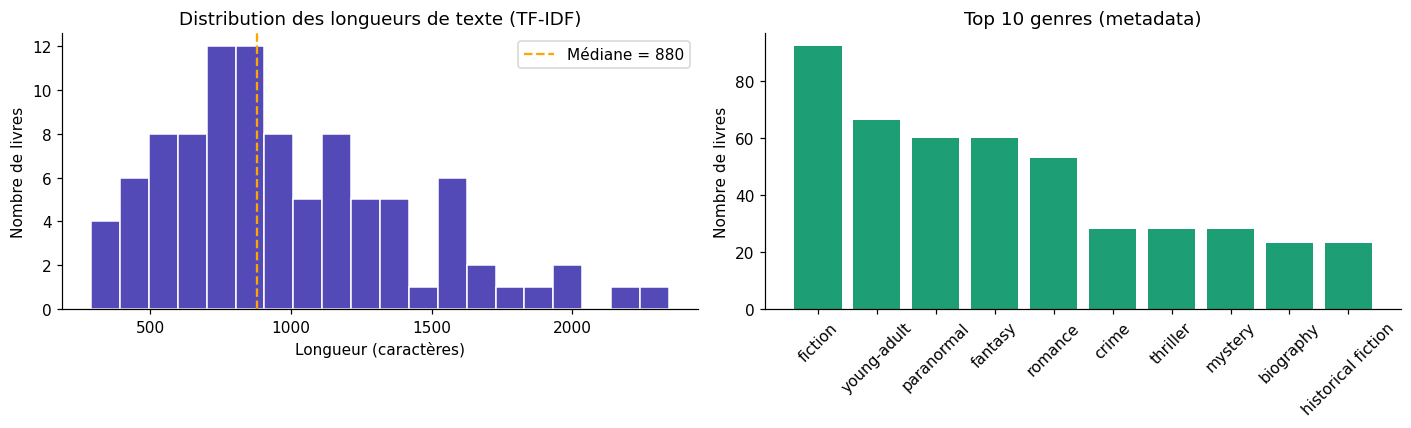

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme longueurs
axes[0].hist(tfidf_books['text_len'].dropna(), bins=20, color='#534AB7', edgecolor='white')
axes[0].set_title('Distribution des longueurs de texte (TF-IDF)')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Nombre de livres')
axes[0].axvline(tfidf_books['text_len'].median(), color='orange', linestyle='--',
                label=f"Médiane = {tfidf_books['text_len'].median():.0f}")
axes[0].legend()

# Répartition des genres
counter = Counter()
for g in tfidf_books['genre'].dropna().astype(str):
    for part in g.strip('[]').replace("'", '').split(','):
        p = part.strip().lower()
        if p:
            counter[p] += 1
genre_counts = pd.Series(counter).sort_values(ascending=False)
axes[1].bar(genre_counts.head(10).index, genre_counts.head(10).values, color='#1D9E75')
axes[1].set_title('Top 10 genres (metadata)')
axes[1].set_ylabel('Nombre de livres')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9.3 Vectorisation TF-IDF et matrice de similarité

Avec le TF-IDF les mots fréquents dans un seul livre obtiennent un poids élevé; les mots présents partout (filtrés par `stop_words`) sont écartés. La similarité cosinus compare ensuite ces vecteurs deux à deux.

In [37]:
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf    = vectorizer.fit_transform(tfidf_books['text'])
cos_sim    = cosine_similarity(X_tfidf)

print(f'TF-IDF shape      : {X_tfidf.shape}')
print(f'Vocabulaire       : {len(vectorizer.get_feature_names_out())} termes')
print(f'Cosine sim shape  : {cos_sim.shape}')

TF-IDF shape      : (96, 3746)
Vocabulaire       : 3746 termes
Cosine sim shape  : (96, 96)


In [38]:
titles = tfidf_books['title'].tolist()

def top_similar_books_content(book_index, top_n=5):
    """Recommande les top_n livres les plus similaires par contenu TF-IDF."""
    sims = cos_sim[book_index]
    idx  = np.argsort(sims)[::-1]
    idx  = [i for i in idx if i != book_index][:top_n]
    return [(titles[i], round(sims[i], 4)) for i in idx]

print(f'Livre référence : {titles[0]}')
print('Livres similaires (TF-IDF) :')
for title, score in top_similar_books_content(0, top_n=5):
    print(f'  {score:.4f}  {title}')

Livre référence : Pride and Prejudice and Zombies Pride and Prejudice and Zombies 1
Livres similaires (TF-IDF) :
  0.0509  Saga Vol 2 Saga 2
  0.0506  The Hunt for Red October Jack Ryan Universe 4
  0.0467  Something Borrowed Darcy Rachel 1
  0.0408  Freakonomics A Rogue Economist Explores the Hidden Side of Everything Freakonomics 1
  0.0382  Maus I A Survivors Tale My Father Bleeds History Maus 1


---
## 10. Modèle Content-Based - Jina AI Embeddings Sémantiques

TF-IDF compare des mots exacts. Si deux descriptions utilisent des synonymes ou des tournures différentes pour décrire la même chose, TF-IDF ne le verra pas.

Les embeddings sémantiques résolvent ce problème : un modèle de langage transforme chaque description en vecteur dense qui capture le sens, pas seulement les mots. "Roman policier" et "thriller" seront proches dans cet espace, même si aucun mot n'est partagé.

On utilise ici l'API Jina AI avec le modèle `jina-embeddings-v3`.

In [40]:
import requests
import sys

os.environ['JINA_API_KEY'] = 'jina_8331ad8ef26a435f998106ee9ccdaa4dTIUwqGAJ-vPVLx3Io5QNGYZ-drma'  # ← remplir avec votre clé API
JINA_API_KEY = os.getenv('JINA_API_KEY')
JINA_URL     = 'https://api.jina.ai/v1/embeddings'
MODELE       = 'jina-embeddings-v3'

def charger_livres(chemin):
    df = pd.read_csv(chemin)
    df['texte'] = df['description'].fillna('') + ' ' + df['genre'].fillna('')
    return df.reset_index(drop=True)

def obtenir_embeddings(textes):
    if not JINA_API_KEY:
        sys.exit('JINA_API_KEY manquante.')
    reponse = requests.post(
        JINA_URL,
        headers={'Authorization': f'Bearer {JINA_API_KEY}', 'Content-Type': 'application/json'},
        json={'model': MODELE, 'input': textes},
        timeout=60,
    )
    reponse.raise_for_status()
    return [item['embedding'] for item in reponse.json()['data']]

def recommander_jina(titre, df, matrice_sim, top_n=5):
    masque = df['title'].str.lower().str.contains(titre.lower(), na=False)
    if not masque.any():
        print(f"Titre '{titre}' introuvable.")
        return pd.DataFrame()
    idx     = masque.idxmax()
    scores  = matrice_sim[idx]
    resultats = (
        pd.Series(scores, index=df['title'])
        .drop(df.loc[idx, 'title'], errors='ignore')
        .nlargest(top_n)
        .reset_index()
    )
    resultats.columns = ['Titre', 'Similarité']
    return resultats

print('Fonctions Jina définies ')

Fonctions Jina définies 


In [41]:
df_jina  = charger_livres('../data/collaborative_book_metadata.csv')
print(f'{len(df_jina)} livres chargés.')

print('Génération des embeddings Jina AI...')
vecteurs    = obtenir_embeddings(df_jina['texte'].tolist())
matrice_sim = cosine_similarity(vecteurs)
print('Embeddings générés ')

96 livres chargés.
Génération des embeddings Jina AI...
Embeddings générés 


In [42]:
titres_test = ['Pride and Prejudice', 'Harry Potter', 'Hunger Games']

for titre in titres_test:
    print(f'\nLivres similaires à : « {titre} »')
    print('-' * 50)
    resultats = recommander_jina(titre, df_jina, matrice_sim, top_n=5)
    if not resultats.empty:
        display(resultats)


Livres similaires à : « Pride and Prejudice »
--------------------------------------------------


,Titre,Similarité
0,Living Dead in Dallas Sookie Stackhouse 2,0.575040
1,Betrayed House of Night 2,0.564120
2,Lover Mine Black Dagger Brotherhood 8,0.561146
3,The Son of Neptune The Heroes of Olympus 2,0.559699
4,From Dead to Worse Sookie Stackhouse 8,0.558619



Livres similaires à : « Harry Potter »
--------------------------------------------------


,Titre,Similarité
0,Harry Potter and the Cursed Child Parts One an...,0.666072
1,Harry Potter and the Cursed Child Parts 1 2 Ha...,0.653241
2,The Chronicles of Narnia Chronicles of Narnia 17,0.604754
3,WinniethePooh WinniethePooh 1,0.561174
4,A Clash of Kings A Song of Ice and Fire 2,0.547452



Livres similaires à : « Hunger Games »
--------------------------------------------------
Titre 'Hunger Games' introuvable.


---
## 11. Synthèse et comparaison des approches

### Tableau récapitulatif

In [43]:
synthese = pd.DataFrame({
    'Approche': [
        'Item-Item Cosine (baseline)',
        'ALS Implicite',
        'ALS + Clustering K-Means',
        'TF-IDF Cosine',
        'Jina Embeddings'
    ],
    'Type': [
        'Collaboratif', 'Collaboratif', 'Collaboratif + Clustering',
        'Contenu', 'Contenu'
    ],
    'Nb livres couverts': [898, 898, 898, 96, 96],
    'Cold start user': ['Non', 'Oui (popularité)', 'Oui (popularité)', 'N/A', 'N/A'],
    'Cold start item': ['Non', 'Non', 'Oui (cluster)', 'Oui (texte)', 'Oui (texte)'],
    'Complexité mémoire': ['O(n²)', 'O(n·k)', 'O(n·k)', 'O(n·v)', 'O(n·d)'],
    'Signal utilisé': [
        'Notes brutes', 'Likes binarisés + BM25',
        'Likes binarisés + BM25', 'Description + Genre', 'Description + Genre'
    ]
})

display(synthese.set_index('Approche'))

,Type,Nb livres couverts,Cold start user,Cold start item,Complexité mémoire,Signal utilisé
Approche,,,,,,
Item-Item Cosine (baseline),Collaboratif,898,Non,Non,O(n²),Notes brutes
ALS Implicite,Collaboratif,898,Oui (popularité),Non,O(n·k),Likes binarisés + BM25
ALS + Clustering K-Means,Collaboratif + Clustering,898,Oui (popularité),Oui (cluster),O(n·k),Likes binarisés + BM25
TF-IDF Cosine,Contenu,96,N/A,Oui (texte),O(n·v),Description + Genre
Jina Embeddings,Contenu,96,N/A,Oui (texte),O(n·d),Description + Genre


### Conclusion

Ce projet nous a permis de construire et comparer cinq approches de recommandation sur un même dataset.

**Du côté collaboratif**, la baseline item-item cosinus est simple à mettre en oeuvre mais souffre de plusieurs problèmes structurels : traitement indifférencié des notes positives et négatives, absence de gestion du cold start, et matrice de similarité dense non scalable. Le modèle ALS corrige ces points grâce à la binarisation des likes, la pondération BM25 et la gestion explicite des utilisateurs inconnus. Le clustering sur les embeddings ALS ajoute une couche d'interprétabilité et ouvre la voie à des recommandations plus rapides sur de grands catalogues.

**Du côté contenu**, TF-IDF offre une approche simple et interprétable, limitée à la correspondance lexicale exacte. Les embeddings Jina dépassent cette limite en capturant la sémantique, au prix d'une dépendance à une API externe.

**Prochaine étape** : une évaluation formelle avec Precision@K et MAP@K permettra de comparer quantitativement ces approches sur des données de test séparées.